🚀 Iniciando descarga directa desde Google Drive (Big Data)...
🔬 Iniciando autopsia de campo (1.46 GB)


/tmp/ipython-input-1385323897.py:39: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,12) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(reader):


⚡ 250,000 líneas procesadas... Balance: -20346.06
⚡ 1,250,000 líneas procesadas... Balance: -117306.13
⚡ 2,250,000 líneas procesadas... Balance: -203208.55
⚡ 3,250,000 líneas procesadas... Balance: -219814.96


/tmp/ipython-input-1385323897.py:39: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(reader):


⚡ 4,250,000 líneas procesadas... Balance: -250006.14
⚡ 5,250,000 líneas procesadas... Balance: -343717.82
⚡ 6,250,000 líneas procesadas... Balance: -424720.43


...

⚡ 7,250,000 líneas procesadas... Balance: -487833.26


/tmp/ipython-input-1385323897.py:39: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(reader):


⚡ 8,250,000 líneas procesadas... Balance: -538209.77
⚡ 9,250,000 líneas procesadas... Balance: -538209.77
⚡ 10,250,000 líneas procesadas... Balance: -582824.75
⚡ 11,250,000 líneas procesadas... Balance: -671770.80
⚡ 12,250,000 líneas procesadas... Balance: -772118.63
⚡ 13,250,000 líneas procesadas... Balance: -874287.02
⚡ 14,250,000 líneas procesadas... Balance: -968886.83


/tmp/ipython-input-1385323897.py:39: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(reader):



═════════════════════════════════════════════
💎 INFORME FINAL DE INVESTIGACIÓN ARC
Registros Totales: 14,990,121
Profit Neto Final: -992581.61
═════════════════════════════════════════════


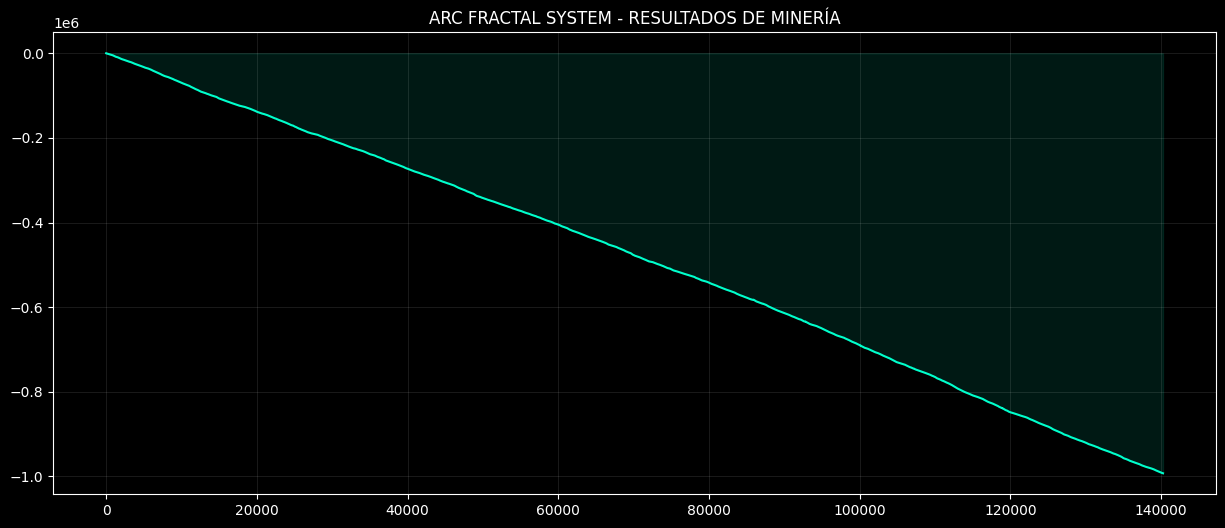


🏆 TOP INTERSECCIONES POR PROFIT:
                  n              p
LOCK_M10_H1    1312   -9375.979974
LOCK_H1_H6     2020  -13816.080010
LOCK_M2_M10    2396  -16536.269967
LOCK_H1_H12    3910  -27277.669998
LOCK_M10_H6    4480  -29068.140000
LOCK_M2_H1     4638  -35518.109975
H3_ZERO        4956  -36824.460022
LOCK_M2_H6     6175  -38459.500001
LOCK_M10_H12   8069  -56035.830005
LOCK_M2_H12   10698  -82225.169997
H1_INT        20632 -154155.480000
A_M10_H12     22787 -157045.909979
A_M2_H1       23798 -169289.350056
A_M2_M10      24846 -171855.500012
A_H1_H12      25571 -174254.680030


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# =================================================================
# 1. CONFIGURACIÓN DE DESCARGA DIRECTA
# =================================================================
# He insertado tu ID: 1Lm6ycHXnNf4hlWjamU-XI742O0_dsqkS
FILE_ID = '1Lm6ycHXnNf4hlWjamU-XI742O0_dsqkS'
FILE_NAME = 'ARC_20260212_2125_Audit.csv'

def descargar_archivo(file_id, output_name):
    if not os.path.exists(output_name):
        print("🚀 Iniciando descarga directa desde Google Drive (Big Data)...")
        # gdown es la herramienta estándar de Colab para esto
        os.system(f'gdown --id {file_id} -O {output_name}')
    else:
        print("✅ El archivo ya existe en el entorno local.")

# =================================================================
# 2. MOTOR DE PROCESAMIENTO ESTRUCTURAL
# =================================================================
COLUMNS = [
    'Timestamp', 'Price', 'N_M2', 'N_M10', 'N_H1', 'N_H6', 'N_H12',
    'S_M2', 'Energy', 'Score', 'Event', 'Action', 'Profit', 'Comment'
]

def analizar_resonancia_fractal(path):
    print(f"🔬 Iniciando autopsia de campo ({os.path.getsize(path)/(1024**3):.2f} GB)")

    equity = [0]
    resonancia_stats = {}
    total_filas = 0

    # Streaming: Bloques de 250,000 para proteger la RAM
    reader = pd.read_csv(path, names=COLUMNS, header=None,
                         on_bad_lines='skip', chunksize=250000, engine='c')

    for i, chunk in enumerate(reader):
        total_filas += len(chunk)

        # Optimización de memoria
        chunk['Profit'] = pd.to_numeric(chunk['Profit'], errors='coerce').fillna(0).astype('float32')
        chunk['Score'] = pd.to_numeric(chunk['Score'], errors='coerce').fillna(0).astype('int8')

        # Filtrar trades (Shadow Trading)
        trades = chunk[chunk['Profit'] != 0]

        for _, row in trades.iterrows():
            equity.append(equity[-1] + row['Profit'])

            # Desglosar eventos de la Matriz Pentagonal
            if isinstance(row['Event'], str) and row['Event'] != 'NONE':
                eventos = row['Event'].split('|')
                for ev in eventos:
                    if not ev: continue
                    if ev not in resonancia_stats: resonancia_stats[ev] = {'n': 0, 'p': 0.0}
                    resonancia_stats[ev]['n'] += 1
                    resonancia_stats[ev]['p'] += row['Profit']

        if i % 4 == 0:
            print(f"⚡ {total_filas:,} líneas procesadas... Balance: {equity[-1]:.2f}")

    # =================================================================
    # 3. RESULTADOS VISUALES
    # =================================================================
    print("\n" + "═"*45)
    print("💎 INFORME FINAL DE INVESTIGACIÓN ARC")
    print(f"Registros Totales: {total_filas:,}")
    print(f"Profit Neto Final: {equity[-1]:.2f}")
    print("═"*45)

    plt.style.use('dark_background')
    plt.figure(figsize=(15, 6))
    plt.plot(equity, color='#00ffcc', linewidth=1.5, label='Curva de Equidad ARC')
    plt.fill_between(range(len(equity)), equity, color='#00ffcc', alpha=0.1)
    plt.title('ARC FRACTAL SYSTEM - RESULTADOS DE MINERÍA')
    plt.grid(True, alpha=0.1)
    plt.show()

    if resonancia_stats:
        df_res = pd.DataFrame.from_dict(resonancia_stats, orient='index')
        print("\n🏆 TOP INTERSECCIONES POR PROFIT:")
        print(df_res.sort_values(by='p', ascending=False).head(15))

# --- EJECUCIÓN ---
descargar_archivo(FILE_ID, FILE_NAME)
analizar_resonancia_fractal(FILE_NAME)